#Step 1: Download & Extract Dataset

# Upload kaggle.json before running
# Kaggle API key is NOT included in repository for security reasons

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip -d /content/ham10000
!ls /content/ham10000

Streaming output truncated to the last 5000 lines.
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029340.jpg  


#Step 2: Check Images + Metadata

In [ ]:
import pandas as pd
from glob import glob
import os

base = "/content/ham10000"
part1 = os.path.join(base, "HAM10000_images_part_1")
part2 = os.path.join(base, "HAM10000_images_part_2")

meta_csv = os.path.join(base, "HAM10000_metadata.csv")
df = pd.read_csv(meta_csv)

print("Metadata shape:", df.shape)
print(df.head())

imgs = glob(os.path.join(part1, "*.jpg")) + glob(os.path.join(part2, "*.jpg"))
print("Total images:", len(imgs))


Metadata shape: (10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Total images: 10015


#Step 3: Attach Filepaths to Metadata

In [ ]:
def path_for_id(img_id):
    p1 = f"/content/ham10000/HAM10000_images_part_1/{img_id}.jpg"
    p2 = f"/content/ham10000/HAM10000_images_part_2/{img_id}.jpg"
    return p1 if os.path.exists(p1) else p2 if os.path.exists(p2) else None

df['filepath'] = df['image_id'].apply(path_for_id)
print("Missing filepaths:", df['filepath'].isna().sum())
df.head()

Missing filepaths: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,filepath
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000/HAM10000_images_part_2/ISIC_...


#Step 4: Stratified Train/Val/Test Split
This ensures all 7 classes are balanced across splits.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1, stratify=train_df['dx'], random_state=42)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Train class distribution:\n", train_df['dx'].value_counts())

Train: (7210, 8) Val: (802, 8) Test: (2003, 8)
Train class distribution:
 dx
nv       4827
mel       801
bkl       791
bcc       370
akiec     236
vasc      102
df         83
Name: count, dtype: int64


#Step 5: Data Pipeline with Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Training data generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

# Validation & test generator (only rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from dataframe
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 7210 validated image filenames belonging to 7 classes.
Found 802 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


#Step 6: Verify Batches

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Training data generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

# Validation & test generator (only rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from dataframe
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 7210 validated image filenames belonging to 7 classes.
Found 802 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
# Get number of classes from generator
num_classes = len(train_gen.class_indices)
print("Number of classes:", num_classes)


Number of classes: 7


#Step 7: Build Custom CNN

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),   # clean way to define input

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,108,039 (19.49 MB)

 Trainable params: 5,108,039 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

#Add Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]


#Step 8: Train the Model

In [ ]:
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,   # Increased from 10 → 30
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 181s 758ms/step - accuracy: 0.6475 - loss: 1.1841 - val_accuracy: 0.6696 - val_loss: 0.9380 - learning_rate: 0.0010
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 142s 627ms/step - accuracy: 0.6729 - loss: 0.9792 - val_accuracy: 0.6708 - val_loss: 0.9120 - learning_rate: 0.0010
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 141s 625ms/step - accuracy: 0.6806 - loss: 0.9412 - val_accuracy: 0.6733 - val_loss: 0.8626 - learning_rate: 0.0010
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 140s 620ms/step - accuracy: 0.6623 - loss: 0.9442 - val_accuracy: 0.6746 - val_loss: 0.8508 - learning_rate: 0.0010
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 145s 644ms/step - accuracy: 0.6736 - loss: 0.9162 - val_accuracy: 0.6733 - val_loss: 0.9091 - learning_rate: 0.0010
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 141s 625ms/step - accuracy: 0.6780 - loss: 0.9237 - val_accuracy: 0.6721 - val_loss: 0.8329 - learning_rate: 0.0010
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 142s 629ms/step - accura

#Step 9: Evaluate on Test Data

In [ ]:
test_loss, test_acc = cnn_model.evaluate(test_gen)
print("Test Accuracy (Custom CNN):", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.7123 - loss: 0.7451
Test Accuracy (Custom CNN): 0.7299051284790039


#Step 10:Plot Training Curves

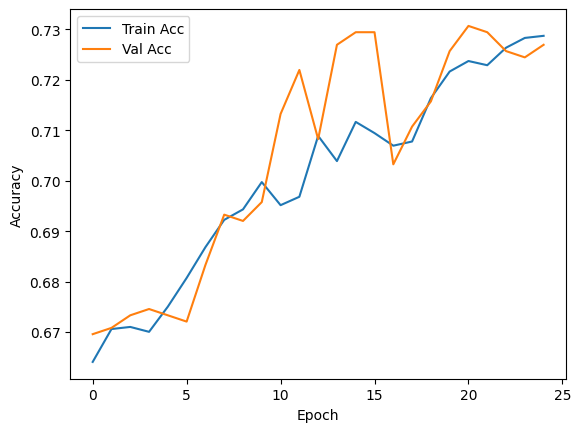

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Step 11: Predictions on Test Data

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred_probs = cnn_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_gen.classes

# Class labels
class_labels = list(test_gen.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step


#Step 12: Confusion Matrix

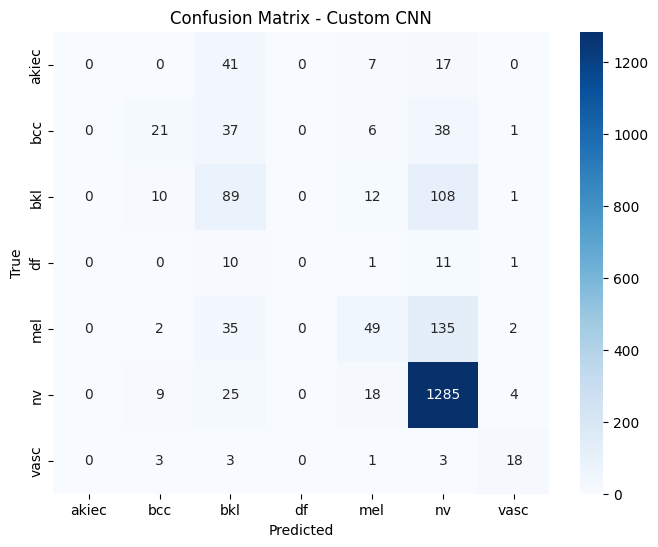

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Custom CNN")
plt.show()


#Step 13: Classification Report

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.47      0.20      0.28       103
         bkl       0.37      0.40      0.39       220
          df       0.00      0.00      0.00        23
         mel       0.52      0.22      0.31       223
          nv       0.80      0.96      0.87      1341
        vasc       0.67      0.64      0.65        28

    accuracy                           0.73      2003
   macro avg       0.40      0.35      0.36      2003
weighted avg       0.67      0.73      0.69      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# compute class weights based on training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(4.364406779661017), 1: np.float64(2.7837837837837838), 2: np.float64(1.302149178255373), 3: np.float64(12.409638554216867), 4: np.float64(1.285892634207241), 5: np.float64(0.21338305365651544), 6: np.float64(10.098039215686274)}


#Step 1: Import ResNet50 (pretrained on ImageNet)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import layers, optimizers

# Number of classes
num_classes = len(train_gen.class_indices)

# Load ResNet50 without the top (fully connected) layers
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base model layers (so we only train the classifier head first)
for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


#Step 2: Add Custom Classification Head

In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=predictions)

#Step 3: Compile Model

In [ ]:
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#Step 4: Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet50.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=5, verbose=1, min_lr=1e-6)
]

# Train initial head
history_resnet = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks   # <-- now it uses the full list
)

Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 162s 712ms/step - accuracy: 0.3289 - loss: 1.6883 - val_accuracy: 0.3416 - val_loss: 1.6276 - learning_rate: 4.0000e-07
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 145s 642ms/step - accuracy: 0.3036 - loss: 1.6773 - val_accuracy: 0.3304 - val_loss: 1.6316 - learning_rate: 4.0000e-07
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 154s 681ms/step - accuracy: 0.3041 - loss: 1.6798 - val_accuracy: 0.3204 - val_loss: 1.6127 - learning_rate: 4.0000e-07
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 199s 669ms/step - accuracy: 0.3013 - loss: 1.7289 - val_accuracy: 0.3242 - val_loss: 1.5851 - learning_rate: 4.0000e-07
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 149s 657ms/step - accuracy: 0.2992 - loss: 1.6579 - val_accuracy: 0.3067 - val_loss: 1.6481 - learning_rate: 4.0000e-07
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 203s 661ms/step - accuracy: 0.3164 - loss: 1.6589 - val_accuracy: 0.2494 - val_loss: 1.7127 - learning_rate: 4.0000e-07
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 

#3. Unfreeze Last Layers and Fine-Tune

In [ ]:
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True


# Recompile with a lower learning rate
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

# Add learning rate scheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1)

# Fine-tune the model
history_resnet_ft = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,   # more training
    callbacks=callbacks + [lr_scheduler],
    class_weight=class_weights
)


Epoch 1/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 194s 729ms/step - accuracy: 0.2803 - loss: 1.7380 - val_accuracy: 0.4065 - val_loss: 1.5599 - learning_rate: 1.0000e-05
Epoch 2/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 153s 676ms/step - accuracy: 0.3088 - loss: 1.7376 - val_accuracy: 0.5037 - val_loss: 1.3324 - learning_rate: 1.0000e-05
Epoch 3/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 152s 671ms/step - accuracy: 0.3590 - loss: 1.6158 - val_accuracy: 0.4489 - val_loss: 1.3090 - learning_rate: 1.0000e-05
Epoch 4/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 147s 648ms/step - accuracy: 0.3765 - loss: 1.6468 - val_accuracy: 0.3653 - val_loss: 1.5975 - learning_rate: 1.0000e-05
Epoch 5/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 145s 641ms/step - accuracy: 0.3706 - loss: 1.6239 - val_accuracy: 0.1434 - val_loss: 1.9175 - learning_rate: 1.0000e-05
Epoch 6/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.3394 - loss: 1.6069
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
226/226 ━━━━━━━━━━━━━━━━━━━━ 150s 6

#Step 5: Evaluate on Test Set

In [ ]:
test_loss, test_acc = resnet_model.evaluate(test_gen)
print("Test Accuracy (ResNet50):", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.4450 - loss: 1.3485
Test Accuracy (ResNet50): 0.4463305175304413


#Step 6: Confusion Matrix + Classification Report

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step


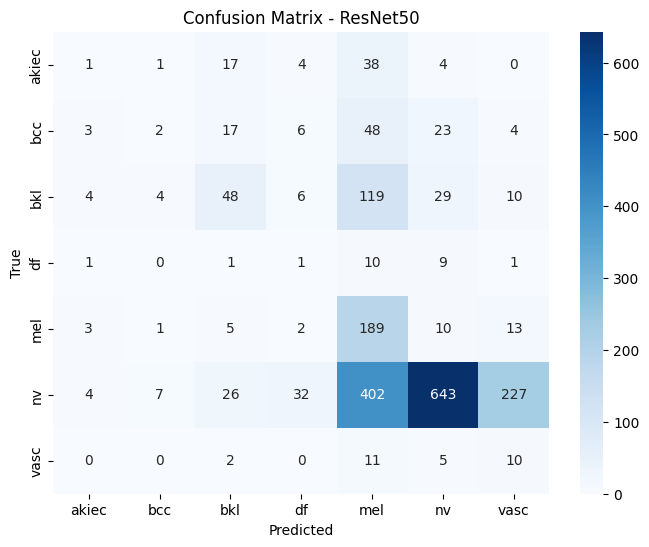

Classification Report:
               precision    recall  f1-score   support

       akiec       0.06      0.02      0.02        65
         bcc       0.13      0.02      0.03       103
         bkl       0.41      0.22      0.29       220
          df       0.02      0.04      0.03        23
         mel       0.23      0.85      0.36       223
          nv       0.89      0.48      0.62      1341
        vasc       0.04      0.36      0.07        28

    accuracy                           0.45      2003
   macro avg       0.26      0.28      0.20      2003
weighted avg       0.68      0.45      0.49      2003



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = resnet_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n", report)
